# 86 — Is the already-known-share coefficient alpha?

Notebook 85's surviving test **T3** says that, within a session, firms whose news
flow is a higher share of restated headlines earn lower next-session abnormal
returns, after mean sentiment, negative share and news volume:
**−0.00882, 95% HAC(5) [−0.01387, −0.00376], BH q=0.0019**, 2,263 development
sessions.

A rank coefficient with a small p-value is not alpha. This notebook does three
things, in this order, with the rule frozen in
`frozen_specs/already_known_share_economic_value_v1_20260814.json`:

1. **Magnitude** — translate the coefficient into basis points via a within-session
   quintile sort.
2. **Mechanism** — M1 repeat polarity, M2 the firm's own price path, M3 an
   exact-repeat-only definition, M4 story-count and calendar-year stability.
3. **Price it** — a dollar-neutral book at the programme's standard 10 bps/side,
   both as a raw `known_share` sort and as the *conditional residual* that the
   coefficient actually describes.

**The declared alpha gate** (all five, on development): positive net Sharpe at 10
bps/side; break-even ≥ 10 bps/side; block-bootstrap lower bound on mean net return
above zero; positive net Sharpe in both development halves; and the coefficient
survives M2 with the same sign. Failure means the null is recorded, not that a
rescue is searched.

**Evaluation-block disclosure.** 2020–2023 is *already open* — Notebook 75 ran the
preregistered beyond-the-mean family there once, and Notebook 81 has already
applied a development-selected rule to it as exploratory background. The replay in
section 7 is computed **after** the development gate is written, applied unchanged
and once. T3 is the surviving member of a three-test development family, so this is
a retrospective check on a selected signal, not independent validation.

In [1]:
from __future__ import annotations

import hashlib
import json
import sqlite3
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "final_experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.aggregators import HARD_LABEL  # noqa: E402
from final_experiments.lib.conditional_aggregation import hac_mean_coefficient  # noqa: E402
from final_experiments.lib.distribution import polarity_label  # noqa: E402
from final_experiments.lib.evaluate import (  # noqa: E402
    TradeConfig,
    block_bootstrap_mean,
    build_daily_portfolio,
    summarize_daily_portfolio,
)
from final_experiments.lib.novelty_conditioning import (  # noqa: E402
    PRIMARY_JACCARD_THRESHOLD,
    daily_rank_regression,
    flag_already_known,
    residualise_within_session,
)
from final_experiments.lib.panel import (  # noqa: E402
    DEFAULT_EVENTS_DB,
    DEFAULT_PRICE_ZIP,
    load_adjusted_open_prices,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    ORDINAL_BLUE,
    annotate_source,
    apply_house_style,
    zero_line,
)

apply_house_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

OUTPUT = ROOT / "final_experiments/outputs/86_fnspid_already_known_share_economic_value"
OUTPUT.mkdir(parents=True, exist_ok=True)
SPEC_PATH = ROOT / "final_experiments/frozen_specs/already_known_share_economic_value_v1_20260814.json"
NOVELTY_PATH = ROOT / "final_experiments/outputs/02_filters_and_distribution/story_novelty.parquet"
PANEL_PATH = ROOT / "final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet"

OUTCOME = "ar_open_h1"
MIN_NAMES = 10
HAC_LAGS = 5
BLOCK = 20
REPLICATIONS = 9_999
SEED = 20_260_814
COST_SWEEP = [0.0, 1.0, 2.0, 5.0, 10.0]
CHARGED_COST = 10.0

BASE_T3 = ["mean_continuous", "negative_share", "known_share", "log1p_n"]
PRICE_CONTROLS = ["lagged_return_1", "lagged_return_5", "sigma20"]
RESIDUAL_CONTROLS = ["mean_continuous", "negative_share", "log1p_n"]


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def summarise(daily: pd.DataFrame, column: str, *, label: str) -> dict[str, Any]:
    summary = hac_mean_coefficient(daily, coefficient_col=column, hac_lags=HAC_LAGS)
    return {
        "model": label,
        "sessions": int(summary["n_clusters"]),
        "estimate": float(summary["estimate"]),
        "ci_low": float(summary["ci_low"]),
        "ci_high": float(summary["ci_high"]),
        "p": float(summary["p_two_sided"]),
    }

## 1. Frozen rule and input identity

In [2]:
spec = json.loads(SPEC_PATH.read_text())
if spec["status"] != "frozen_before_notebook_86_result":
    raise ValueError("unexpected frozen-spec status")

input_audit = pd.DataFrame(
    [
        {
            "input": name,
            "expected_sha256": entry["sha256"],
            "actual_sha256": sha256(Path(entry["path"]) if Path(entry["path"]).is_absolute() else ROOT / entry["path"]),
        }
        for name, entry in spec["inputs"].items()
    ]
)
input_audit["match"] = input_audit["expected_sha256"] == input_audit["actual_sha256"]
if not input_audit["match"].all():
    raise ValueError("input hash mismatch")
input_audit.to_csv(OUTPUT / "input_audit.csv", index=False)
display(input_audit[["input", "match"]])
display(Markdown("**Alpha gate:** " + "; ".join(spec["alpha_gate"]["conditions"]) + "."))

,input,match
0,fnspid_firm_day_aggregators,True
1,fnspid_story_novelty,True
2,fnspid_finbert_checkpoint,True
3,fnspid_price_archive,True


**Alpha gate:** positive net Sharpe at the charged 10 bps per side; break-even cost at least equal to the 10 bps per side charged; block-bootstrap lower bound on mean net return above zero; positive net Sharpe in both temporal halves of the development block; the coefficient survives the M2 price-path controls with the same sign.

## 2. Build the firm-day frame

`known_share` is split by the polarity of the repeated stories so M1 can ask
whether restated *bad* news is doing the work. `known_share_exact` uses only exact
normalized-hash repeats (M3). Both blocks are built now; no evaluation return is
read until section 7.

In [3]:
panel = pd.read_parquet(PANEL_PATH)
panel["session_date"] = pd.to_datetime(panel["session_date"]).dt.normalize()
panel["symbol"] = panel["symbol"].astype(str).str.upper()

novelty = pd.read_parquet(
    NOVELTY_PATH,
    columns=["event_key", "symbol", "session_date", "exact_repeat_in_window", "max_jaccard_in_window"],
)
novelty["session_date"] = pd.to_datetime(novelty["session_date"]).dt.normalize()
novelty["symbol"] = novelty["symbol"].astype(str).str.upper()

connection = sqlite3.connect(f"file:{DEFAULT_EVENTS_DB}?mode=ro", uri=True)
try:
    scores = pd.read_sql_query(
        "SELECT event_key, finbert_score, p_negative, p_neutral, p_positive FROM events", connection
    )
finally:
    connection.close()

stories = novelty.merge(scores, on="event_key", how="inner", validate="one_to_one")
stories["is_negative"] = (polarity_label(stories).map(HARD_LABEL).astype(float) < 0).astype(float)
stories["is_known"] = flag_already_known(stories, jaccard_threshold=PRIMARY_JACCARD_THRESHOLD).astype(float)
stories["is_known_exact"] = stories["exact_repeat_in_window"].astype(float)
stories["known_negative"] = stories["is_known"] * stories["is_negative"]
stories["known_nonnegative"] = stories["is_known"] * (1.0 - stories["is_negative"])

firm_day = (
    stories.groupby(["symbol", "session_date"], sort=False)
    .agg(
        n_stories=("finbert_score", "size"),
        known_share=("is_known", "mean"),
        known_share_exact=("is_known_exact", "mean"),
        known_share_negative=("known_negative", "mean"),
        known_share_nonnegative=("known_nonnegative", "mean"),
    )
    .reset_index()
)

analysis = panel.merge(firm_day, on=["symbol", "session_date"], how="inner", validate="one_to_one")
if not analysis["n"].eq(analysis["n_stories"]).all():
    raise RuntimeError("story counts disagree with the published panel")
analysis["log1p_n"] = np.log1p(analysis["n"].astype(float))
if not np.allclose(
    analysis["known_share"], analysis["known_share_negative"] + analysis["known_share_nonnegative"], atol=1e-12
):
    raise RuntimeError("polarity decomposition does not reconcile to known_share")

In [4]:
prices, missing_symbols = load_adjusted_open_prices(
    DEFAULT_PRICE_ZIP,
    set(analysis["symbol"].unique()),
    start="2010-01-01",
    end="2023-12-31",
)
prices = prices.sort_values(["symbol", "session_date"], kind="mergesort").copy()
groups = prices.groupby("symbol", sort=False)
prices["lagged_return_1"] = groups["adjusted_open"].pct_change(fill_method=None)
prices["lagged_return_5"] = prices["adjusted_open"].div(groups["adjusted_open"].shift(5)).sub(1.0)
prices["sigma20"] = prices.groupby("symbol", sort=False)["lagged_return_1"].transform(
    lambda values: values.rolling(20, min_periods=20).std(ddof=1)
)
analysis = analysis.merge(
    prices.loc[prices["symbol"].ne("SPY"), ["symbol", "session_date", *PRICE_CONTROLS]],
    on=["symbol", "session_date"],
    how="left",
    validate="m:1",
)

development = analysis.loc[analysis["split"].eq("development")].copy()
evaluation = analysis.loc[analysis["split"].eq("evaluation")].copy()

frame_audit = pd.DataFrame(
    [
        {
            "block": name,
            "firm_days": int(len(block)),
            "sessions": int(block["session_date"].nunique()),
            "symbols": int(block["symbol"].nunique()),
            "mean_known_share": float(block["known_share"].mean()),
            "price_control_coverage": float(block[PRICE_CONTROLS].notna().all(axis=1).mean()),
        }
        for name, block in (("development", development), ("evaluation", evaluation))
    ]
)
frame_audit.to_csv(OUTPUT / "frame_audit.csv", index=False)
display(frame_audit)
if missing_symbols:
    display(Markdown(f"Price archive is missing {len(missing_symbols)} symbols; their price-control rows drop from M2 only."))

,block,firm_days,sessions,symbols,mean_known_share,price_control_coverage
0,development,512153,2264,570,0.094843,0.999594
1,evaluation,203393,998,570,0.142670,1.000000


## 3. Magnitude — what is −0.0088 worth in basis points?

In [5]:
# Most firm-days have `known_share == 0`, so quintile edges fall inside a large tie
# block. Ties are broken by a seeded shuffle rather than by row order, which is
# alphabetical by symbol and would otherwise sort names into buckets systematically.
quintile_rows: list[dict[str, Any]] = []
daily_spread_rows: list[dict[str, Any]] = []
tie_rng = np.random.default_rng(SEED)
for session, day in development.dropna(subset=[OUTCOME, "known_share"]).groupby("session_date", sort=True):
    if len(day) < MIN_NAMES or day["known_share"].nunique() < 2:
        continue
    day = day.sample(frac=1.0, random_state=int(tie_rng.integers(0, 2**32)))
    buckets = pd.qcut(day["known_share"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
    means = day.groupby(buckets, observed=True)[OUTCOME].mean()
    for bucket, value in means.items():
        quintile_rows.append({"session_date": session, "quintile": int(bucket), "mean_ar": float(value)})
    if {1, 5}.issubset(set(means.index.astype(int))):
        daily_spread_rows.append(
            {"session_date": session, "spread": float(means.loc[5] - means.loc[1])}
        )

quintiles = pd.DataFrame(quintile_rows)
quintile_summary = (
    quintiles.groupby("quintile")["mean_ar"]
    .agg(sessions="size", mean_ar="mean")
    .assign(mean_ar_bps=lambda frame: frame["mean_ar"] * 10_000.0)
    .reset_index()
)
daily_spread = pd.DataFrame(daily_spread_rows)
spread_boot = block_bootstrap_mean(
    daily_spread["spread"].to_numpy(dtype=float), block_length=BLOCK, replications=REPLICATIONS, seed=SEED
)
spread_summary = pd.DataFrame(
    [
        {
            "statistic": "Q5 minus Q1 mean AR, bps/session",
            "sessions": int(len(daily_spread)),
            "estimate_bps": spread_boot["mean"] * 10_000.0,
            "ci_low_bps": spread_boot["ci_low"] * 10_000.0,
            "ci_high_bps": spread_boot["ci_high"] * 10_000.0,
        }
    ]
)
quintile_summary.to_csv(OUTPUT / "known_share_quintiles.csv", index=False)
spread_summary.to_csv(OUTPUT / "known_share_quintile_spread.csv", index=False)
display(quintile_summary)
display(spread_summary)

,quintile,sessions,mean_ar,mean_ar_bps
0,1,2263,0.000002,0.023089
1,2,2263,-0.000018,-0.175978
2,3,2263,-0.000022,-0.221895
3,4,2263,0.000039,0.391190
4,5,2263,-0.000191,-1.908580


,statistic,sessions,estimate_bps,ci_low_bps,ci_high_bps
0,"Q5 minus Q1 mean AR, bps/session",2263,-1.931669,-3.828286,-0.104912


findfont: Failed to find font weight medium, now using 400.


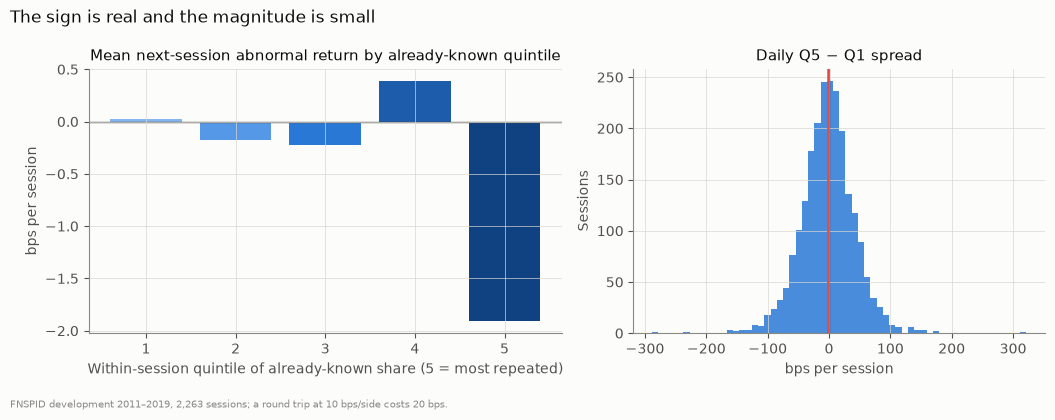

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9), gridspec_kw={"width_ratios": [1.15, 1.0]})

axes[0].bar(
    quintile_summary["quintile"].astype(str),
    quintile_summary["mean_ar_bps"],
    color=list(ORDINAL_BLUE),
)
zero_line(axes[0], axis="y")
axes[0].set_title("Mean next-session abnormal return by already-known quintile")
axes[0].set_xlabel("Within-session quintile of already-known share (5 = most repeated)")
axes[0].set_ylabel("bps per session")

axes[1].hist(daily_spread["spread"] * 10_000.0, bins=60, color=CATEGORICAL[0], alpha=0.85)
zero_line(axes[1], axis="x")
axes[1].axvline(spread_boot["mean"] * 10_000.0, color=CATEGORICAL[7], lw=1.8)
axes[1].set_title("Daily Q5 − Q1 spread")
axes[1].set_xlabel("bps per session")
axes[1].set_ylabel("Sessions")

fig.suptitle("The sign is real and the magnitude is small", ha="left", x=0.0)
annotate_source(
    fig,
    f"FNSPID development 2011–2019, {len(daily_spread):,} sessions; a round trip at 10 bps/side costs 20 bps.",
)
fig.tight_layout()
fig.savefig(OUTPUT / "magnitude_quintiles.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Mechanism — is it repetition, or something wearing repetition's clothes?

In [7]:
mechanism_rows: list[dict[str, Any]] = []

base_daily, base_audit = daily_rank_regression(
    development, date_col="session_date", outcome_col=OUTCOME, regressor_cols=BASE_T3, min_names=MIN_NAMES
)
mechanism_rows.append({**summarise(base_daily, "beta_known_share", label="T3 base (replication)"), "check": "base"})

m1_regressors = ["mean_continuous", "negative_share", "known_share_negative", "known_share_nonnegative", "log1p_n"]
m1_daily, _ = daily_rank_regression(
    development, date_col="session_date", outcome_col=OUTCOME, regressor_cols=m1_regressors, min_names=MIN_NAMES
)
mechanism_rows.append({**summarise(m1_daily, "beta_known_share_negative", label="M1 repeated negative stories"), "check": "M1"})
mechanism_rows.append(
    {**summarise(m1_daily, "beta_known_share_nonnegative", label="M1 repeated non-negative stories"), "check": "M1"}
)

price_complete = development.dropna(subset=PRICE_CONTROLS).copy()
m2_same_sample, _ = daily_rank_regression(
    price_complete, date_col="session_date", outcome_col=OUTCOME, regressor_cols=BASE_T3, min_names=MIN_NAMES
)
mechanism_rows.append(
    {**summarise(m2_same_sample, "beta_known_share", label="M2 same sample, no price controls"), "check": "M2"}
)
m2_daily, _ = daily_rank_regression(
    price_complete,
    date_col="session_date",
    outcome_col=OUTCOME,
    regressor_cols=[*BASE_T3, *PRICE_CONTROLS],
    min_names=MIN_NAMES,
)
mechanism_rows.append({**summarise(m2_daily, "beta_known_share", label="M2 with price-path controls"), "check": "M2"})

m3_regressors = ["mean_continuous", "negative_share", "known_share_exact", "log1p_n"]
m3_daily, _ = daily_rank_regression(
    development, date_col="session_date", outcome_col=OUTCOME, regressor_cols=m3_regressors, min_names=MIN_NAMES
)
mechanism_rows.append({**summarise(m3_daily, "beta_known_share_exact", label="M3 exact repeats only"), "check": "M3"})

mechanisms = pd.DataFrame(mechanism_rows)
mechanisms.to_csv(OUTPUT / "mechanism_checks.csv", index=False)
display(mechanisms[["check", "model", "sessions", "estimate", "ci_low", "ci_high", "p"]])

m2_survives = bool(
    mechanisms.loc[mechanisms["model"].eq("M2 with price-path controls"), "estimate"].item() < 0
    and mechanisms.loc[mechanisms["model"].eq("M2 with price-path controls"), "ci_high"].item() < 0
)

,check,model,sessions,estimate,ci_low,ci_high,p
0,base,T3 base (replication),2263,-0.008815,-0.013872,-0.003758,0.000634
1,M1,M1 repeated negative stories,2196,-0.001759,-0.016068,0.012551,0.809657
2,M1,M1 repeated non-negative stories,2196,-0.009622,-0.015034,-0.004210,0.000492
3,M2,"M2 same sample, no price controls",2263,-0.008790,-0.013848,-0.003732,0.000659
4,M2,M2 with price-path controls,2263,-0.007737,-0.012737,-0.002738,0.002420
5,M3,M3 exact repeats only,2236,-0.008565,-0.021684,0.004554,0.200700


In [8]:
# M4a. A fixed-`n` bin cannot carry this model: `log1p_n` is constant inside it, so
# every session is dropped as a constant regressor. Cumulative thresholds preserve
# the news-volume control while still removing the small-`n` days, so they are what
# the stratum question can actually be asked with. The degenerate bin is reported
# rather than hidden.
stratum_rows: list[dict[str, Any]] = []
fixed_bin = development.loc[development["n"].eq(1)]
stratum_rows.append(
    {
        "stratum": "n = 1 (fixed bin)",
        "firm_days": int(len(fixed_bin)),
        "sessions": 0,
        "estimate": np.nan,
        "ci_low": np.nan,
        "ci_high": np.nan,
        "p": np.nan,
        "status": "not estimable — log1p_n is constant within a fixed-n bin",
    }
)
for minimum in (1, 2, 3, 6):
    subset = development.loc[development["n"] >= minimum]
    daily, _ = daily_rank_regression(
        subset, date_col="session_date", outcome_col=OUTCOME, regressor_cols=BASE_T3, min_names=MIN_NAMES
    )
    row = summarise(daily, "beta_known_share", label="")
    stratum_rows.append(
        {
            "stratum": "all firm-days" if minimum == 1 else f"n ≥ {minimum}",
            "firm_days": int(len(subset)),
            **{key: value for key, value in row.items() if key != "model"},
            "status": "estimated",
        }
    )
strata = pd.DataFrame(stratum_rows)
strata.to_csv(OUTPUT / "story_count_strata.csv", index=False)
display(strata)

year_rows: list[dict[str, Any]] = []
base_daily_year = base_daily.assign(year=base_daily["session_date"].dt.year)
for year, group in base_daily_year.groupby("year"):
    row = summarise(group, "beta_known_share", label="")
    year_rows.append({"year": int(year), **{k: v for k, v in row.items() if k != "model"}})
years = pd.DataFrame(year_rows)
years.to_csv(OUTPUT / "yearly_coefficients.csv", index=False)
display(years)

,stratum,firm_days,sessions,estimate,ci_low,ci_high,p,status
0,n = 1 (fixed bin),247470,0,NaN,NaN,NaN,NaN,not estimable — log1p_n is constant within a f...
1,all firm-days,512153,2263,-0.008815,-0.013872,-0.003758,0.000634,estimated
2,n ≥ 2,264683,2263,-0.008273,-0.014567,-0.001979,0.009987,estimated
3,n ≥ 3,137142,2261,-0.005285,-0.013802,0.003231,0.223854,estimated
4,n ≥ 6,32186,1389,-0.012915,-0.033120,0.007289,0.210256,estimated


,year,sessions,estimate,ci_low,ci_high,p
0,2011,251,-0.009487,-0.028439,0.009465,0.326517
1,2012,250,-0.007629,-0.021576,0.006318,0.283679
2,2013,252,-0.018007,-0.035016,-0.000998,0.037994
3,2014,252,-0.026151,-0.041878,-0.010423,0.001118
4,2015,252,0.007108,-0.008636,0.022851,0.376240
5,2016,252,-0.013280,-0.025263,-0.001298,0.029841
6,2017,251,-0.002422,-0.015161,0.010317,0.709423
7,2018,251,0.009103,-0.004862,0.023068,0.201416
8,2019,252,-0.018467,-0.030206,-0.006729,0.002046


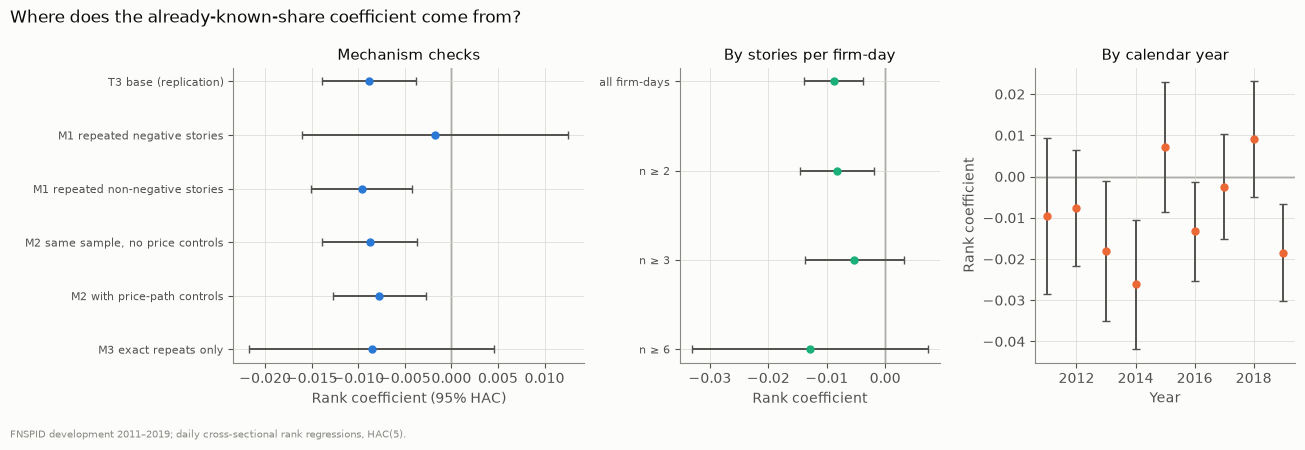

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.2), gridspec_kw={"width_ratios": [1.35, 1.0, 1.0]})

forest = mechanisms.iloc[::-1].reset_index(drop=True)
positions = np.arange(len(forest))
axes[0].errorbar(
    forest["estimate"],
    positions,
    xerr=[forest["estimate"] - forest["ci_low"], forest["ci_high"] - forest["estimate"]],
    fmt="o",
    color=CATEGORICAL[0],
    ecolor=INK["secondary"],
    capsize=3,
    lw=1.4,
)
axes[0].set_yticks(positions)
axes[0].set_yticklabels(forest["model"], fontsize=8)
zero_line(axes[0], axis="x")
axes[0].set_xlabel("Rank coefficient (95% HAC)")
axes[0].set_title("Mechanism checks")

plotted = strata.dropna(subset=["estimate"])
axes[1].errorbar(
    plotted["estimate"],
    np.arange(len(plotted)),
    xerr=[plotted["estimate"] - plotted["ci_low"], plotted["ci_high"] - plotted["estimate"]],
    fmt="o",
    color=CATEGORICAL[2],
    ecolor=INK["secondary"],
    capsize=3,
    lw=1.4,
)
axes[1].set_yticks(np.arange(len(plotted)))
axes[1].set_yticklabels(plotted["stratum"], fontsize=8)
axes[1].invert_yaxis()
zero_line(axes[1], axis="x")
axes[1].set_xlabel("Rank coefficient")
axes[1].set_title("By stories per firm-day")

axes[2].errorbar(
    years["year"],
    years["estimate"],
    yerr=[years["estimate"] - years["ci_low"], years["ci_high"] - years["estimate"]],
    fmt="o",
    color=CATEGORICAL[1],
    ecolor=INK["secondary"],
    capsize=3,
    lw=1.4,
)
zero_line(axes[2], axis="y")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Rank coefficient")
axes[2].set_title("By calendar year")

fig.suptitle("Where does the already-known-share coefficient come from?", ha="left", x=0.0)
annotate_source(fig, "FNSPID development 2011–2019; daily cross-sectional rank regressions, HAC(5).")
fig.tight_layout()
fig.savefig(OUTPUT / "mechanism_forest.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Price it

**B1** trades the raw `known_share` sort. **B2** trades the within-session rank
residual after mean sentiment, negative share and log news count — the quantity the
T3 coefficient actually describes. Both are dollar-neutral, one-session holds, and
both are shorted on high repeat share (`orient = -1`).

In [10]:
analysis["known_share_residual"] = residualise_within_session(
    analysis,
    date_col="session_date",
    target_col="known_share",
    control_cols=RESIDUAL_CONTROLS,
    min_names=MIN_NAMES,
)
development = analysis.loc[analysis["split"].eq("development")].copy()
evaluation = analysis.loc[analysis["split"].eq("evaluation")].copy()

config = TradeConfig(cost_bps_per_side=CHARGED_COST, outcome=OUTCOME)
books = {
    "B1 raw known_share": "known_share",
    "B2 conditional residual": "known_share_residual",
}
development_daily: dict[str, pd.DataFrame] = {}
book_rows: list[dict[str, Any]] = []
for label, column in books.items():
    daily = build_daily_portfolio(development, column, config=config, orient=-1.0, split="development")
    development_daily[label] = daily
    summary = summarize_daily_portfolio(daily, config=config)
    half = len(daily) // 2
    book_rows.append(
        {
            "book": label,
            "sessions": summary["n_sessions"],
            "mean_gross_bps": summary["mean_gross"] * 10_000.0,
            "mean_net_bps": summary["mean_net"] * 10_000.0,
            "sharpe_gross": summary["sharpe_gross"],
            "sharpe_net": summary["sharpe_net"],
            "annualised_turnover": summary["annualized_turnover"],
            "breakeven_bps_per_side": summary["breakeven_bps_per_side"],
            "net_ci_low_bps": summary["bootstrap_net_ci_low"] * 10_000.0,
            "net_ci_high_bps": summary["bootstrap_net_ci_high"] * 10_000.0,
            "mean_net_exposure": summary["mean_net_exposure"],
            "sharpe_net_first_half": float(
                daily.iloc[:half]["net_return"].mean() / daily.iloc[:half]["net_return"].std(ddof=1) * np.sqrt(252)
            ),
            "sharpe_net_second_half": float(
                daily.iloc[half:]["net_return"].mean() / daily.iloc[half:]["net_return"].std(ddof=1) * np.sqrt(252)
            ),
            "net_ending_return": float((1.0 + daily["net_return"]).prod() - 1.0),
        }
    )
development_books = pd.DataFrame(book_rows)
development_books.to_csv(OUTPUT / "development_books.csv", index=False)
display(development_books.T.rename(columns=lambda index: development_books["book"].iloc[index]).drop(index="book"))

if development_books["mean_net_exposure"].abs().max() > 1e-9:
    raise RuntimeError("book is not dollar-neutral")

,B1 raw known_share,B2 conditional residual
sessions,2264,2263
mean_gross_bps,1.296196,0.746320
mean_net_bps,-12.171554,-14.433961
sharpe_gross,1.040325,0.707404
sharpe_net,-9.753868,-13.650725
annualised_turnover,169.693650,191.271544
breakeven_bps_per_side,0.962445,0.491638
net_ci_low_bps,-12.892303,-15.131206
net_ci_high_bps,-11.409028,-13.799811
mean_net_exposure,-0.000000,-0.000000


In [11]:
sweep_rows = []
for label, daily in development_daily.items():
    for cost in COST_SWEEP:
        net = daily["gross_return"] - 2.0 * daily["turnover"] * cost / 10_000.0
        sweep_rows.append(
            {
                "book": label,
                "cost_bps_per_side": cost,
                "mean_net_bps": float(net.mean()) * 10_000.0,
                "sharpe_net": float(net.mean() / net.std(ddof=1) * np.sqrt(252)),
            }
        )
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(OUTPUT / "cost_sweep.csv", index=False)
display(sweep.pivot(index="cost_bps_per_side", columns="book", values="sharpe_net"))

book,B1 raw known_share,B2 conditional residual
cost_bps_per_side,,
0.000000,1.040325,0.707404
1.000000,-0.040596,-0.731416
2.000000,-1.121531,-2.169958
5.000000,-4.363121,-6.482445
10.000000,-9.753868,-13.650725


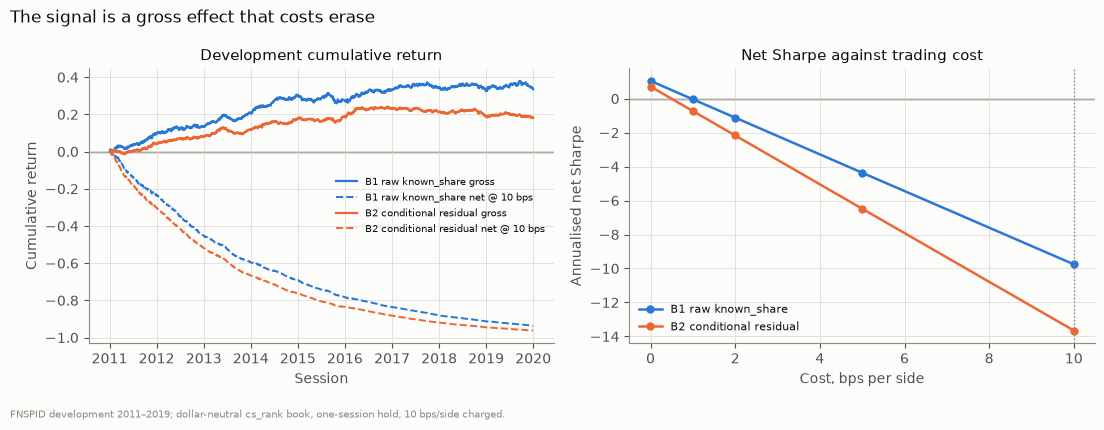

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

for (label, daily), colour in zip(development_daily.items(), (CATEGORICAL[0], CATEGORICAL[1]), strict=True):
    axes[0].plot(
        daily["session_date"], (1.0 + daily["gross_return"]).cumprod() - 1.0, color=colour, lw=1.6, label=f"{label} gross"
    )
    axes[0].plot(
        daily["session_date"],
        (1.0 + daily["net_return"]).cumprod() - 1.0,
        color=colour,
        lw=1.4,
        ls="--",
        label=f"{label} net @ {CHARGED_COST:.0f} bps",
    )
zero_line(axes[0], axis="y")
axes[0].set_title("Development cumulative return")
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Cumulative return")
axes[0].legend(frameon=False, fontsize=7.5)

for (label, group), colour in zip(sweep.groupby("book"), (CATEGORICAL[0], CATEGORICAL[1]), strict=True):
    axes[1].plot(group["cost_bps_per_side"], group["sharpe_net"], color=colour, marker="o", lw=1.8, label=label)
zero_line(axes[1], axis="y")
axes[1].axvline(CHARGED_COST, color=INK["muted"], lw=1.0, ls=":")
axes[1].set_title("Net Sharpe against trading cost")
axes[1].set_xlabel("Cost, bps per side")
axes[1].set_ylabel("Annualised net Sharpe")
axes[1].legend(frameon=False, fontsize=8)

fig.suptitle("The signal is a gross effect that costs erase", ha="left", x=0.0)
annotate_source(fig, "FNSPID development 2011–2019; dollar-neutral cs_rank book, one-session hold, 10 bps/side charged.")
fig.tight_layout()
fig.savefig(OUTPUT / "economic_translation.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Development gate — written before the evaluation block is touched

In [13]:
primary_book = development_books.loc[development_books["book"].eq("B2 conditional residual")].iloc[0]
gate = pd.DataFrame(
    [
        {"condition": "net Sharpe > 0 at 10 bps/side", "value": primary_book["sharpe_net"], "passes": bool(primary_book["sharpe_net"] > 0)},
        {
            "condition": "break-even >= 10 bps/side",
            "value": primary_book["breakeven_bps_per_side"],
            "passes": bool(primary_book["breakeven_bps_per_side"] >= CHARGED_COST),
        },
        {
            "condition": "bootstrap lower bound on mean net > 0",
            "value": primary_book["net_ci_low_bps"],
            "passes": bool(primary_book["net_ci_low_bps"] > 0),
        },
        {
            "condition": "net Sharpe > 0 in both halves",
            "value": min(primary_book["sharpe_net_first_half"], primary_book["sharpe_net_second_half"]),
            "passes": bool(primary_book["sharpe_net_first_half"] > 0 and primary_book["sharpe_net_second_half"] > 0),
        },
        {
            "condition": "coefficient survives M2 price controls with the same sign",
            "value": float(mechanisms.loc[mechanisms["model"].eq("M2 with price-path controls"), "estimate"].item()),
            "passes": m2_survives,
        },
    ]
)
gate.to_csv(OUTPUT / "alpha_gate.csv", index=False)
display(gate)
gate_passes = bool(gate["passes"].all())
display(Markdown(f"### Development alpha gate: **{'PASS' if gate_passes else 'FAIL'}** ({int(gate['passes'].sum())}/5 conditions)"))

,condition,value,passes
0,net Sharpe > 0 at 10 bps/side,-13.650725,False
1,break-even >= 10 bps/side,0.491638,False
2,bootstrap lower bound on mean net > 0,-15.131206,False
3,net Sharpe > 0 in both halves,-14.556278,False
4,coefficient survives M2 price controls with th...,-0.007737,True


### Development alpha gate: **FAIL** (1/5 conditions)

## 7. One unchanged replay on the already-opened evaluation block

Retrospective and exploratory, in the same role as Notebook 81. The rule, cost,
horizon and orientation are exactly those frozen above.

In [14]:
eval_daily_coeff, _ = daily_rank_regression(
    evaluation, date_col="session_date", outcome_col=OUTCOME, regressor_cols=BASE_T3, min_names=MIN_NAMES
)
coefficient_blocks = pd.DataFrame(
    [
        {**summarise(base_daily, "beta_known_share", label="development 2011–2019"), "block": "development"},
        {**summarise(eval_daily_coeff, "beta_known_share", label="evaluation 2020–2023"), "block": "evaluation"},
    ]
)
coefficient_blocks.to_csv(OUTPUT / "coefficient_by_block.csv", index=False)
display(coefficient_blocks[["block", "sessions", "estimate", "ci_low", "ci_high", "p"]])

evaluation_daily: dict[str, pd.DataFrame] = {}
eval_rows = []
for label, column in books.items():
    daily = build_daily_portfolio(evaluation, column, config=config, orient=-1.0, split="evaluation")
    evaluation_daily[label] = daily
    summary = summarize_daily_portfolio(daily, config=config)
    eval_rows.append(
        {
            "book": label,
            "sessions": summary["n_sessions"],
            "mean_gross_bps": summary["mean_gross"] * 10_000.0,
            "mean_net_bps": summary["mean_net"] * 10_000.0,
            "sharpe_gross": summary["sharpe_gross"],
            "sharpe_net": summary["sharpe_net"],
            "breakeven_bps_per_side": summary["breakeven_bps_per_side"],
            "net_ci_low_bps": summary["bootstrap_net_ci_low"] * 10_000.0,
            "net_ci_high_bps": summary["bootstrap_net_ci_high"] * 10_000.0,
            "net_ending_return": float((1.0 + daily["net_return"]).prod() - 1.0),
        }
    )
evaluation_books = pd.DataFrame(eval_rows)
evaluation_books.to_csv(OUTPUT / "evaluation_books.csv", index=False)
display(evaluation_books.T.rename(columns=lambda index: evaluation_books["book"].iloc[index]).drop(index="book"))

,block,sessions,estimate,ci_low,ci_high,p
0,development,2263,-0.008815,-0.013872,-0.003758,0.000634
1,evaluation,997,0.003366,-0.004609,0.011341,0.408125


,B1 raw known_share,B2 conditional residual
sessions,998,997
mean_gross_bps,-0.279768,-0.192201
mean_net_bps,-13.909060,-15.418711
sharpe_gross,-0.087668,-0.061946
sharpe_net,-4.360531,-4.969007
breakeven_bps_per_side,-0.205269,-0.126228
net_ci_low_bps,-16.757861,-17.776867
net_ci_high_bps,-11.573376,-13.096909
net_ending_return,-0.753936,-0.787774


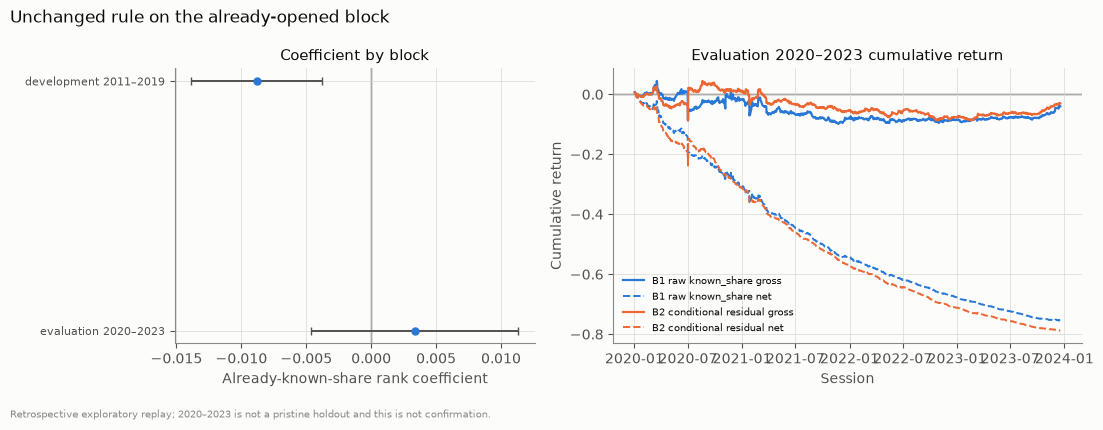

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), gridspec_kw={"width_ratios": [1.0, 1.3]})

positions = np.arange(len(coefficient_blocks))
axes[0].errorbar(
    coefficient_blocks["estimate"],
    positions,
    xerr=[
        coefficient_blocks["estimate"] - coefficient_blocks["ci_low"],
        coefficient_blocks["ci_high"] - coefficient_blocks["estimate"],
    ],
    fmt="o",
    color=CATEGORICAL[0],
    ecolor=INK["secondary"],
    capsize=3,
    lw=1.4,
)
axes[0].set_yticks(positions)
axes[0].set_yticklabels(coefficient_blocks["model"], fontsize=8)
axes[0].invert_yaxis()
zero_line(axes[0], axis="x")
axes[0].set_xlabel("Already-known-share rank coefficient")
axes[0].set_title("Coefficient by block")

for (label, daily), colour in zip(evaluation_daily.items(), (CATEGORICAL[0], CATEGORICAL[1]), strict=True):
    axes[1].plot(daily["session_date"], (1.0 + daily["gross_return"]).cumprod() - 1.0, color=colour, lw=1.6, label=f"{label} gross")
    axes[1].plot(daily["session_date"], (1.0 + daily["net_return"]).cumprod() - 1.0, color=colour, lw=1.4, ls="--", label=f"{label} net")
zero_line(axes[1], axis="y")
axes[1].set_title("Evaluation 2020–2023 cumulative return")
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Cumulative return")
axes[1].legend(frameon=False, fontsize=7.5)

fig.suptitle("Unchanged rule on the already-opened block", ha="left", x=0.0)
annotate_source(fig, "Retrospective exploratory replay; 2020–2023 is not a pristine holdout and this is not confirmation.")
fig.tight_layout()
fig.savefig(OUTPUT / "evaluation_replay.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Verdict

In [16]:
lines = [
    f"# Notebook 86 verdict — {'alpha gate PASSES' if gate_passes else 'not alpha'}",
    "",
    f"- Development alpha gate: {int(gate['passes'].sum())}/5 conditions pass.",
    f"- Q5−Q1 already-known spread: {spread_summary['estimate_bps'].item():.2f} bps/session "
    f"[{spread_summary['ci_low_bps'].item():.2f}, {spread_summary['ci_high_bps'].item():.2f}] "
    f"against a {2 * CHARGED_COST:.0f}-bps round trip.",
    f"- M2 price-path controls: coefficient {mechanisms.loc[mechanisms['model'].eq('M2 with price-path controls'), 'estimate'].item():.5f} "
    f"(same sign: {m2_survives}).",
    "- The 2020–2023 replay is retrospective and exploratory; the block was already opened by Notebook 75, "
    "and T3 was selected on development.",
    "",
    "## Development books",
    "",
    "```",
    development_books[
        ["book", "sessions", "mean_gross_bps", "mean_net_bps", "sharpe_gross", "sharpe_net", "breakeven_bps_per_side"]
    ].to_string(index=False),
    "```",
    "",
    "## Alpha gate",
    "",
    "```",
    gate.to_string(index=False),
    "```",
    "",
    "## Evaluation replay",
    "",
    "```",
    evaluation_books[
        ["book", "sessions", "mean_gross_bps", "mean_net_bps", "sharpe_gross", "sharpe_net", "breakeven_bps_per_side"]
    ].to_string(index=False),
    "```",
    "",
    "## Coefficient by block",
    "",
    "```",
    coefficient_blocks[["block", "sessions", "estimate", "ci_low", "ci_high", "p"]].to_string(index=False),
    "```",
]
verdict = "\n".join(lines) + "\n"
(OUTPUT / "decision.md").write_text(verdict)
display(Markdown(verdict))

# Notebook 86 verdict — not alpha

- Development alpha gate: 1/5 conditions pass.
- Q5−Q1 already-known spread: -1.93 bps/session [-3.83, -0.10] against a 20-bps round trip.
- M2 price-path controls: coefficient -0.00774 (same sign: True).
- The 2020–2023 replay is retrospective and exploratory; the block was already opened by Notebook 75, and T3 was selected on development.

## Development books

```
                   book  sessions  mean_gross_bps  mean_net_bps  sharpe_gross  sharpe_net  breakeven_bps_per_side
     B1 raw known_share      2264        1.296196    -12.171554      1.040325   -9.753868                0.962445
B2 conditional residual      2263        0.746320    -14.433961      0.707404  -13.650725                0.491638
```

## Alpha gate

```
                                                condition      value  passes
                            net Sharpe > 0 at 10 bps/side -13.650725   False
                                break-even >= 10 bps/side   0.491638   False
                    bootstrap lower bound on mean net > 0 -15.131206   False
                            net Sharpe > 0 in both halves -14.556278   False
coefficient survives M2 price controls with the same sign  -0.007737    True
```

## Evaluation replay

```
                   book  sessions  mean_gross_bps  mean_net_bps  sharpe_gross  sharpe_net  breakeven_bps_per_side
     B1 raw known_share       998       -0.279768    -13.909060     -0.087668   -4.360531               -0.205269
B2 conditional residual       997       -0.192201    -15.418711     -0.061946   -4.969007               -0.126228
```

## Coefficient by block

```
      block  sessions  estimate    ci_low   ci_high        p
development      2263 -0.008815 -0.013872 -0.003758 0.000634
 evaluation       997  0.003366 -0.004609  0.011341 0.408125
```
